In [ ]:
# Install required packages
!pip install --upgrade --quiet playwright
!pip install --upgrade --quiet beautifulsoup4
!pip install --upgrade --quiet lxml
!pip install --upgrade --quiet html5lib
!pip install --upgrade --quiet pandas
!pip install --upgrade --quiet nest_asyncio

print('✓ Packages installed!')

**Slides:** [browser-automation.pdf](./browser-automation.pdf)

In this example we are going to scrape [Iowa's Professional Licensing](https://ia-plb.my.site.com/LicenseSearchPage) website for appraisal management companies. (Why? Who knows, why *not?*)

Traditionally Python programmers use [BeautifulSoup](https://beautiful-soup-4.readthedocs.io/en/latest/) to scrape content from the interent. Instead of being *traditional*, we're going to use [Playwright](https://playwright.dev/python/), a **browser automation tool**! This means you actually control the browser! Filling out forms, clicking buttons, downloading documents... it's magic!!!✨✨✨

# Iowa Appraisal Management Companies

- Dropdowns
- Clicking 'Next page' button again and again
- Combining dataframes

## Installation

We need to install a few tools first! Remove the `#` and run the cell to install the Python packages and browsers that we'll need for our scraping adventure.

In [1]:
# %pip install --quiet lxml html5lib beautifulsoup4 pandas
# %pip install --quiet playwright
# !playwright install-deps
# !playwright install chromium firefox

And we'll set it up so Playwright will be sure to work on Windows.

In [2]:
# Detect if we're running in Google Colab
import os
IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

import platform
import asyncio
import nest_asyncio

if platform.system() == "Windows":
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

try:
    asyncio.get_running_loop()
    nest_asyncio.apply()
except RuntimeError:
    pass

## Opening up the browser and visiting our destination


In [3]:
from playwright.async_api import async_playwright

# "Hey, open up a browser"
playwright = await async_playwright().start()

# Colab can't open a visible browser, so we run headless there
if IN_COLAB:
    use_headless = True
else:
    use_headless = False

browser = await playwright.chromium.launch(headless=use_headless)

# Create a new browser window
page = await browser.new_page()

In [4]:
await page.goto("https://ia-plb.my.site.com/LicenseSearchPage")

<Response url='https://ia-plb.my.site.com/LicenseSearchPage' request=<Request url='https://ia-plb.my.site.com/LicenseSearchPage' method='GET'>>

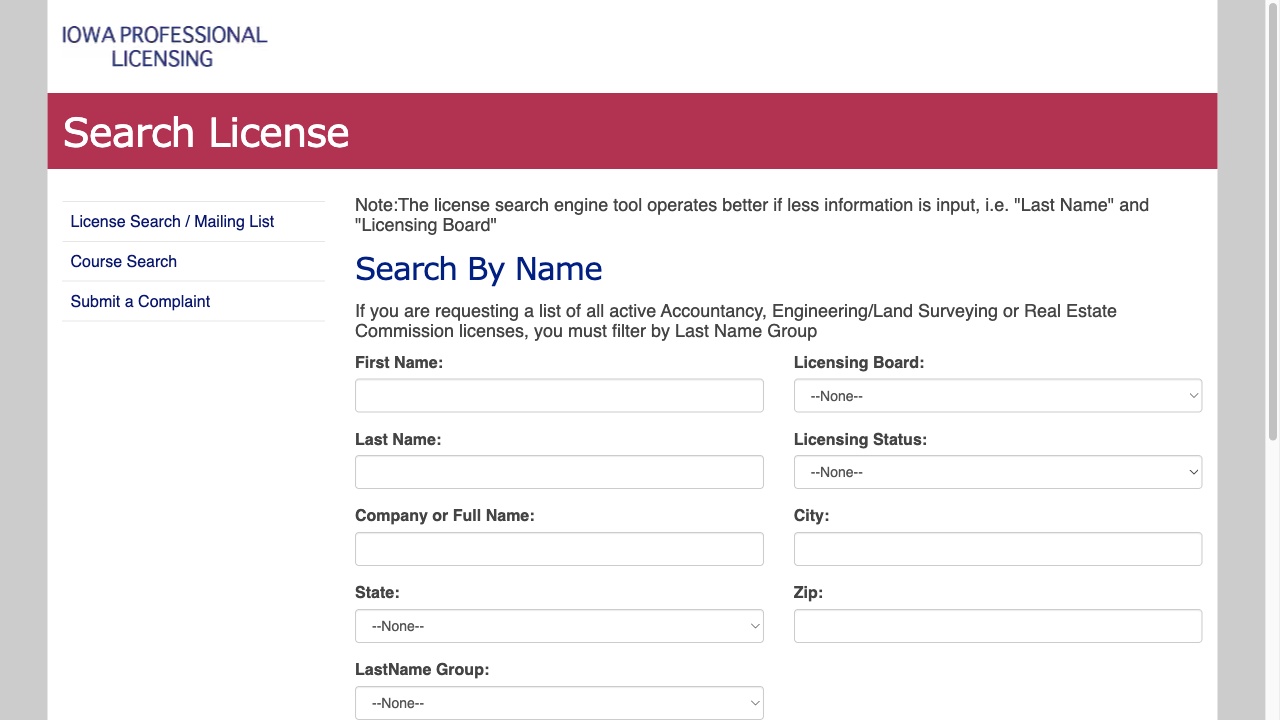

In [5]:
from IPython.display import Image

Image(await page.screenshot())

## Selecting an option from a dropdown

You always start with `await page.locator("select").select_option("whatever option you want")`. You'll probably get an error because there are multiple dropdowns on the page, but Playwright doesn't know which one you want to use! Just read the error and figure out the right one.

In [6]:
# await page.locator("select").select_option("Appraisal Management Company")
await page.get_by_label("Licensing Board:").select_option("Appraisal Management Company")

['Appraisal Management Company']

In [7]:
# await page.get_by_text("Search").click()
await page.locator("input[name=\"j_id0\\:j_id1\\:j_id14\\:j_id73\"]").click()

## Grab the tables from the page

[Pandas](https://pandas.pydata.org/) is the Python equivalent to Excel, and it's great at dealing with tabular data! Often the data on a web page that looks like a spreadsheet can be read with `pd.read_html`.

You use `await page.content()` to save the contents of the page, then feed it to `read_html` to find the tables. `len(tables)` checks the number of tables you have, then you manually poke around to see which one is the one you're interested in. `tables[0]` is the first one, `tables[1]` is the second one, and so on...

In [8]:
import pandas as pd
from io import StringIO

html = await page.content()
tables = pd.read_html(StringIO(html))
len(tables)

1

In [9]:
tables[0]

,Number,Licensee,License Type,Licensing Board,License Status,ContactLastNameGroup
0,00045,if(!window.sfdcPage) { window.sfdcPage = new A...,Appraisal Management Company Registration,Appraisal Management Company,Lapsed,L-Z
1,00028,360 Appraisal Group,Appraisal Management Company Registration,Appraisal Management Company,Expired,A-K
2,00101,AAA APPRAISAL MANAGEMENT COMPANY LLC,Appraisal Management Company Registration,Appraisal Management Company,Active,A-K
3,00132,Accelerated Appraisal Management Company LLC,Appraisal Management Company Registration,Appraisal Management Company,Active,L-Z
4,00034,"Accurate Group, LLC",Appraisal Management Company Registration,Appraisal Management Company,Active,A-K
5,00143,"Accuworth, LLC",Appraisal Management Company Registration,Appraisal Management Company,Active,A-K
6,00012,"ACT Appraisal, Inc.",Appraisal Management Company Registration,Appraisal Management Company,Active,A-K
7,00047,"Allstate Appraisal, L.P.",Appraisal Management Company Registration,Appraisal Management Company,Active,A-K
8,AMC00147,AMC Encore LLC,Appraisal Management Company Registration,Appraisal Management Company,Active,L-Z
9,00097,"AMC Links, LLC",Appraisal Management Company Registration,Appraisal Management Company,Active,L-Z


## Clicking "next page" one

Just like using a dropdown, select box or button, we'll use `page.get_by_text` to try to select the button.

We add `timeout=5000` to wait 5 seconds before confirming it isn't there.

In [10]:
# page.get_by_text("Next Page").click()
await page.locator("a:has-text('Next Page')").click(timeout=5000)

## Clicking "next page" until it disappears

Eventually the "next page" link disappears, and Python starts *screaming*. We use `try/except` down below to say "don't worry little baby, it's okay, we'll just finish up if the button is gone."

When we move this into something nice and repeated, **we need to be careful!** Sometimes the page will load before the table does, so we add a line that says "don't get *too overeager*, wait up to 10 seconds for the table to show up first."

In [11]:
# all of our data will end up going here
all_data = pd.DataFrame()

while True:
    # Wait up to 10 seconds for the table to load
    await page.wait_for_selector("table", timeout=10000)  

    # Get all of the tables on the page
    html = await page.content()
    tables = pd.read_html(StringIO(html))

    # Get the table (and edit if necessary)
    df = tables[0]

    # Add the tables on this page to the big list of stuff
    all_data = pd.concat([all_data, df], ignore_index = True)

    # Save after each page in case something breaks
    all_data.to_csv("output.csv", index=False)

    try:
        await page.locator("a:has-text('Next Page')").click(timeout=5000)
    except:
        break

In [12]:
all_data

,Number,Licensee,License Type,Licensing Board,License Status,ContactLastNameGroup
0,AMC00149,if(!window.sfdcPage) { window.sfdcPage = new A...,Appraisal Management Company Registration,Appraisal Management Company,Active,A-K
1,00081,"Arivs Illinois, LLC",Appraisal Management Company Registration,Appraisal Management Company,Lapsed,L-Z
2,00119,"Arivs, LLC",Appraisal Management Company Registration,Appraisal Management Company,Lapsed,A-K
3,00085,"Ascribe, LLC",Appraisal Management Company Registration,Appraisal Management Company,Active,A-K
4,00031,"Asset Management Outsourcing Services, LLC",Appraisal Management Company Registration,Appraisal Management Company,Lapsed,A-K
...,...,...,...,...,...,...
126,33,"Voxtur Appraisal Services, LLC",Appraisal Management Company Registration,Appraisal Management Company,Lapsed,A-K
127,40,"Voxtur Valuation, LLC",Appraisal Management Company Registration,Appraisal Management Company,Lapsed,A-K
128,142,"Worth Valuation Services, Inc.",Appraisal Management Company Registration,Appraisal Management Company,Active,L-Z
129,20,Xome Settlement Services LLC,Appraisal Management Company Registration,Appraisal Management Company,Expired,A-K


## Saving the results

Now we'll save it to a CSV file! Easy peasy.

In [13]:
all_data.to_csv("output.csv", index=False)